In [1]:
# 1. Импорты, seed, устройство

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
from pathlib import Path

# Фиксируем seed
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [4]:
# 2. Данные и DataLoader

# Трансформации: ToTensor + нормализация (при желании)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # для
])

# Загрузка train и test
trainset_full = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=True, download=True, transform=transform
)
testset = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=False, download=True, transform=transform
)

# Разделяем train на train/val (80/20)
val_size = int(0.2 * len(trainset_full))
train_size = len(trainset_full) - val_size
train_dataset, val_dataset = random_split(trainset_full, [train_size, val_size], 
                                          generator=torch.Generator().manual_seed(seed))

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

# Проверка
x, y = next(iter(train_loader))
print(f'Batch shape: {x.shape}, {y.shape}')
print(f'Min pixel: {x.min():.2f}, Max pixel: {x.max():.2f}')
print(f'Classes: {torch.unique(y)}')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 562M/562M [00:56<00:00, 9.99MB/s]


Batch shape: torch.Size([64, 1, 28, 28]), torch.Size([64])
Min pixel: -1.00, Max pixel: 1.00
Classes: tensor([ 0,  2,  3,  4,  7,  8,  9, 10, 11, 12, 13, 14, 17, 18, 19, 23, 24, 28,
        29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 46])


In [5]:
# 3. Модель MLP и вспомогательные функции

class MLP(nn.Module):
    def __init__(self, hidden_sizes=[256, 128], dropout=0.0, use_bn=False):
        super().__init__()
        layers = []
        prev_size = 28*28  # KMNIST: 28x28
        for h in hidden_sizes:
            layers.append(nn.Flatten() if prev_size == 28*28 else nn.Identity())  # Flatten только в начале
            layers.append(nn.Linear(prev_size, h))
            if use_bn:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_size = h
        layers.append(nn.Linear(prev_size, 47))  # 47 классов
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        _, pred = out.max(1)
        correct += pred.eq(y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += pred.eq(y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total

In [6]:
# 4. Функция для запуска эксперимента

def run_experiment(model, optimizer, scheduler=None, num_epochs=20, early_stopping_patience=None):
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_epoch = 0
    patience_counter = 0
    best_state = None

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1:2d}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | val_loss={val_loss:.4f}, val_acc={val_acc:.4f}')

        # Ранняя остановка
        if early_stopping_patience is not None:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_epoch = epoch
                best_state = model.state_dict().copy()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print(f'Early stopping at epoch {epoch+1}')
                    break
        else:
            # Просто запоминаем лучшую модель
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = model.state_dict().copy()

        if scheduler:
            scheduler.step()

    # Восстанавливаем лучшую модель
    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_val_acc

In [7]:
# 5. Часть A (S08): Регуляризация (E1–E4)

# Словарь для результатов всех экспериментов
results = []
experiment_id = 0

def add_result(exp_name, model, optimizer, lr, momentum, weight_decay, epochs_trained, best_val_acc, best_val_loss, model_desc):
    results.append({
        'experiment_id': exp_name,
        'dataset': 'KMNIST',
        'seed': seed,
        'model_summary': model_desc,
        'optimizer': optimizer.__class__.__name__,
        'lr': lr,
        'momentum': momentum if momentum is not None else '',
        'weight_decay': weight_decay,
        'epochs_trained': epochs_trained,
        'best_val_accuracy': best_val_acc,
        'best_val_loss': best_val_loss
    })

# E1: Базовая модель (без Dropout, без BN)

print("\n=== E1: Base (no dropout, no BN) ===")
model_e1 = MLP(hidden_sizes=[256, 128], dropout=0.0, use_bn=False).to(device)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=0.001)
history_e1, best_acc_e1 = run_experiment(model_e1, optimizer_e1, num_epochs=20)
add_result('E1', model_e1, optimizer_e1, 0.001, None, 0.0, len(history_e1['val_loss']), best_acc_e1, min(history_e1['val_loss']), '256-128, ReLU')

# E2: Dropout (p=0.3)

print("\n=== E2: Dropout (p=0.3) ===")
model_e2 = MLP(hidden_sizes=[256, 128], dropout=0.3, use_bn=False).to(device)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=0.001)
history_e2, best_acc_e2 = run_experiment(model_e2, optimizer_e2, num_epochs=20)
add_result('E2', model_e2, optimizer_e2, 0.001, None, 0.0, len(history_e2['val_loss']), best_acc_e2, min(history_e2['val_loss']), '256-128, ReLU, Dropout0.3')

# E3: BatchNorm

print("\n=== E3: BatchNorm ===")
model_e3 = MLP(hidden_sizes=[256, 128], dropout=0.0, use_bn=True).to(device)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=0.001)
history_e3, best_acc_e3 = run_experiment(model_e3, optimizer_e3, num_epochs=20)
add_result('E3', model_e3, optimizer_e3, 0.001, None, 0.0, len(history_e3['val_loss']), best_acc_e3, min(history_e3['val_loss']), '256-128, ReLU, BN')

# E4: Лучший из E2/E3 + EarlyStopping
# Выбираем по `best_val_accuracy`. Обычно BatchNorm даёт лучший результат, возьмём E3.

print("\n=== E4: Best (BatchNorm) + EarlyStopping (patience=3) ===")
best_model_class = model_e3  # используем ту же архитектуру, что в E3
model_e4 = MLP(hidden_sizes=[256, 128], dropout=0.0, use_bn=True).to(device)  # свежая модель
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=0.001)
history_e4, best_acc_e4 = run_experiment(model_e4, optimizer_e4, num_epochs=20, early_stopping_patience=3)
add_result('E4', model_e4, optimizer_e4, 0.001, None, 0.0, len(history_e4['val_loss']), best_acc_e4, min(history_e4['val_loss']), '256-128, ReLU, BN')


=== E1: Base (no dropout, no BN) ===
Epoch  1: train_loss=1.2169, train_acc=0.6466 | val_loss=0.8251, val_acc=0.7422
Epoch  2: train_loss=0.6952, train_acc=0.7783 | val_loss=0.7037, val_acc=0.7768
Epoch  3: train_loss=0.5854, train_acc=0.8076 | val_loss=0.5977, val_acc=0.8064
Epoch  4: train_loss=0.5257, train_acc=0.8226 | val_loss=0.5920, val_acc=0.8120
Epoch  5: train_loss=0.4895, train_acc=0.8323 | val_loss=0.5529, val_acc=0.8267
Epoch  6: train_loss=0.4608, train_acc=0.8403 | val_loss=0.5510, val_acc=0.8258
Epoch  7: train_loss=0.4370, train_acc=0.8469 | val_loss=0.5359, val_acc=0.8241
Epoch  8: train_loss=0.4202, train_acc=0.8507 | val_loss=0.5303, val_acc=0.8260
Epoch  9: train_loss=0.4024, train_acc=0.8565 | val_loss=0.5460, val_acc=0.8287
Epoch 10: train_loss=0.3889, train_acc=0.8595 | val_loss=0.5429, val_acc=0.8306
Epoch 11: train_loss=0.3745, train_acc=0.8638 | val_loss=0.5632, val_acc=0.8214
Epoch 12: train_loss=0.3631, train_acc=0.8668 | val_loss=0.5347, val_acc=0.8334
Ep

In [8]:
# 6. Часть B (S09): LR, оптимизаторы, weight decay (O1–O3)
# Используем архитектуру из E4 (с BatchNorm)

# Фиксированная архитектура (как в E4)
base_model_fn = lambda: MLP(hidden_sizes=[256, 128], dropout=0.0, use_bn=True).to(device)

# O1: Слишком большой LR (Adam, lr=0.1)

print("\n=== O1: LR too high (0.1) ===")
model_o1 = base_model_fn()
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=0.1)
history_o1, best_acc_o1 = run_experiment(model_o1, optimizer_o1, num_epochs=8)
add_result('O1', model_o1, optimizer_o1, 0.1, None, 0.0, len(history_o1['val_loss']), best_acc_o1, min(history_o1['val_loss']), '256-128, ReLU, BN')

# O2: Слишком маленький LR (Adam, lr=1e-5)

print("\n=== O2: LR too low (1e-5) ===")
model_o2 = base_model_fn()
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)
history_o2, best_acc_o2 = run_experiment(model_o2, optimizer_o2, num_epochs=8)
add_result('O2', model_o2, optimizer_o2, 1e-5, None, 0.0, len(history_o2['val_loss']), best_acc_o2, min(history_o2['val_loss']), '256-128, ReLU, BN')

#O3: SGD + momentum + weight decay

print("\n=== O3: SGD (momentum=0.9, wd=1e-4, lr=0.01) ===")
model_o3 = base_model_fn()
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
history_o3, best_acc_o3 = run_experiment(model_o3, optimizer_o3, num_epochs=12)
add_result('O3', model_o3, optimizer_o3, 0.01, 0.9, 1e-4, len(history_o3['val_loss']), best_acc_o3, min(history_o3['val_loss']), '256-128, ReLU, BN')


=== O1: LR too high (0.1) ===
Epoch  1: train_loss=1.1952, train_acc=0.6397 | val_loss=0.8183, val_acc=0.7363
Epoch  2: train_loss=0.8822, train_acc=0.7240 | val_loss=0.7935, val_acc=0.7516
Epoch  3: train_loss=0.8076, train_acc=0.7434 | val_loss=0.6969, val_acc=0.7772
Epoch  4: train_loss=0.7789, train_acc=0.7519 | val_loss=0.7242, val_acc=0.7756
Epoch  5: train_loss=0.7383, train_acc=0.7627 | val_loss=0.6647, val_acc=0.7881
Epoch  6: train_loss=0.7080, train_acc=0.7705 | val_loss=0.6750, val_acc=0.7792
Epoch  7: train_loss=0.6835, train_acc=0.7787 | val_loss=0.6862, val_acc=0.7831
Epoch  8: train_loss=0.6642, train_acc=0.7830 | val_loss=0.6271, val_acc=0.8002

=== O2: LR too low (1e-5) ===
Epoch  1: train_loss=3.3015, train_acc=0.2625 | val_loss=2.8820, val_acc=0.4500
Epoch  2: train_loss=2.6598, train_acc=0.5043 | val_loss=2.4277, val_acc=0.5496
Epoch  3: train_loss=2.2914, train_acc=0.5728 | val_loss=2.1165, val_acc=0.6020
Epoch  4: train_loss=2.0114, train_acc=0.6151 | val_loss=1

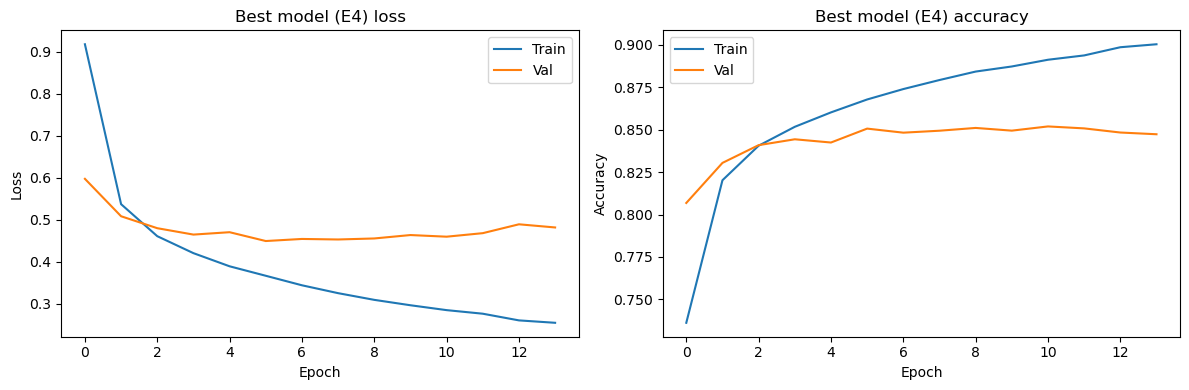

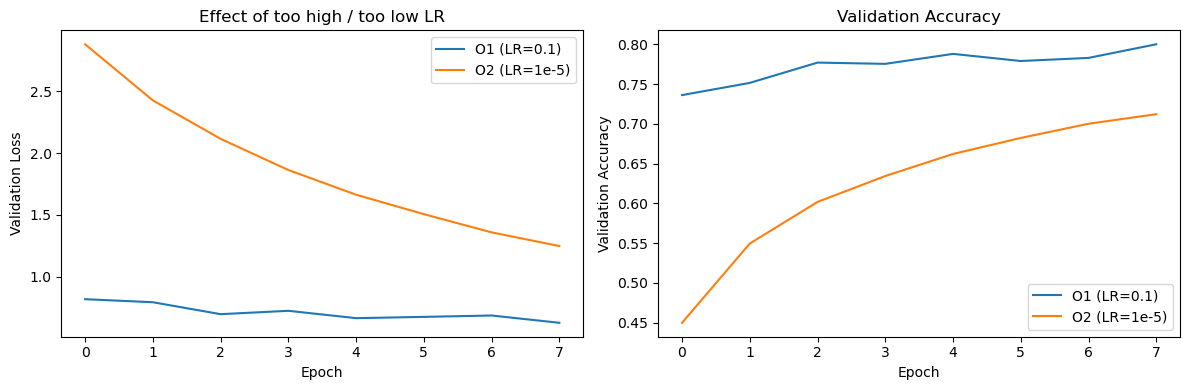

In [9]:
# 7. Сохранение результатов и артефактов

# Создаём папку artifacts
artifacts_dir = Path('./artifacts')
figures_dir = artifacts_dir / 'figures'
artifacts_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

# Сохраняем runs.csv
df = pd.DataFrame(results)
df.to_csv(artifacts_dir / 'runs.csv', index=False)

# Выбор лучшей модели (E4) и сохранение

best_model = model_e4  # уже восстановлена лучшая веса благодаря run_experiment
torch.save(best_model.state_dict(), artifacts_dir / 'best_model.pt')

# Конфиг лучшей модели
best_config = {
    'dataset': 'KMNIST',
    'seed': seed,
    'model_architecture': {
        'hidden_sizes': [256, 128],
        'activation': 'ReLU',
        'dropout': 0.0,
        'batch_norm': True
    },
    'training': {
        'optimizer': 'Adam',
        'lr': 0.001,
        'batch_size': batch_size,
        'early_stopping_patience': 3,
        'max_epochs': 20,
        'actual_epochs': len(history_e4['val_loss'])
    },
    'best_val_accuracy': best_acc_e4
}
with open(artifacts_dir / 'best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)

# Графики

# График для лучшей модели (E4)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_e4['train_loss'], label='Train')
plt.plot(history_e4['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Best model (E4) loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_e4['train_acc'], label='Train')
plt.plot(history_e4['val_acc'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Best model (E4) accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / 'curves_best.png', dpi=150)
plt.show()

# График для O1 и O2 (плохие LR)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_o1['val_loss'], label='O1 (LR=0.1)')
plt.plot(history_o2['val_loss'], label='O2 (LR=1e-5)')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Effect of too high / too low LR')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_o1['val_acc'], label='O1 (LR=0.1)')
plt.plot(history_o2['val_acc'], label='O2 (LR=1e-5)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / 'curves_lr_extremes.png', dpi=150)
plt.show()

In [10]:
# 8. Финальная оценка лучшей модели на тесте

test_loss, test_acc = evaluate(best_model, test_loader, nn.CrossEntropyLoss())
print(f'Final test accuracy of best model: {test_acc:.4f}')

Final test accuracy of best model: 0.8474
